<a href="https://colab.research.google.com/github/dreamrun24/AgriChain/blob/main/greek_mythology_slm_from_scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Greek Mythology Small Language Model — Built from Scratch

**Assignment:** Build a Task-Specific Small Language Model from Scratch  
**Domain:** Greek Mythology (Homer, Hesiod, Apollodorus, Ovid)  
**Model Size:** ~54M parameters  
**Architecture:** GPT-style transformer (decoder-only)  

This notebook trains a GPT-style small language model on classical Greek mythology texts sourced from Project Gutenberg. The model learns to generate mythology-style narrative text.

## Step 1: Install Dependencies

In [ ]:
!pip install tiktoken requests tqdm -q

## Step 2: Assemble the Greek Mythology Dataset

We collect texts from Project Gutenberg — all public domain classical mythology works:
- **The Iliad** — Homer
- **The Odyssey** — Homer
- **Theogony / Works and Days** — Hesiod
- **The Metamorphoses** — Ovid
- **The Library (Bibliotheca)** — Apollodorus
- **Homeric Hymns** — Various

Combined corpus: ~8-10 MB of clean mythology text.

In [ ]:
import requests
import os
import re

# Project Gutenberg URLs for Greek mythology texts
MYTHOLOGY_TEXTS = {
    'iliad':         'https://www.gutenberg.org/cache/epub/2199/pg2199.txt',
    'odyssey':       'https://www.gutenberg.org/cache/epub/1727/pg1727.txt',
    'theogony':      'https://www.gutenberg.org/cache/epub/348/pg348.txt',
    'metamorphoses': 'https://www.gutenberg.org/cache/epub/21765/pg21765.txt',
    'apollodorus':   'https://www.gutenberg.org/cache/epub/45516/pg45516.txt',
    'homeric_hymns': 'https://www.gutenberg.org/cache/epub/22601/pg22601.txt',
}

def download_gutenberg_text(url, title):
    print(f'Downloading {title}...')
    try:
        response = requests.get(url, timeout=30)
        response.raise_for_status()
        text = response.text
        start_markers = [
            '*** START OF THE PROJECT GUTENBERG',
            '*** START OF THIS PROJECT GUTENBERG',
        ]
        end_markers = [
            '*** END OF THE PROJECT GUTENBERG',
            '*** END OF THIS PROJECT GUTENBERG',
            'End of the Project Gutenberg',
            'End of Project Gutenberg',
        ]
        for marker in start_markers:
            idx = text.find(marker)
            if idx != -1:
                text = text[idx + len(marker):]
                nl = text.find('\n')
                if nl != -1:
                    text = text[nl + 1:]
                break
        for marker in end_markers:
            idx = text.find(marker)
            if idx != -1:
                text = text[:idx]
                break
        text = re.sub(r'\r\n', '\n', text)
        text = re.sub(r'\n{4,}', '\n\n\n', text)
        text = text.strip()
        print(f'  -> {title}: {len(text):,} characters')
        return text
    except Exception as e:
        print(f'  -> Failed: {e}')
        return ''

all_texts = []
for title, url in MYTHOLOGY_TEXTS.items():
    text = download_gutenberg_text(url, title)
    if text:
        all_texts.append(text)

full_corpus = '\n\n\n'.join(all_texts)
total_chars = len(full_corpus)
total_words = len(full_corpus.split())

print(f'\n=== CORPUS STATISTICS ===')
print(f'Total characters : {total_chars:,}')
print(f'Total words      : {total_words:,}')
print(f'Approx. size     : {total_chars / 1e6:.2f} MB')

with open('mythology_corpus.txt', 'w', encoding='utf-8') as f:
    f.write(full_corpus)
print('Corpus saved to mythology_corpus.txt')

  -> iliad: 888,886 characters
  -> odyssey: 678,766 characters
  -> theogony: 514,065 characters
  -> metamorphoses: 740,213 characters
  -> apollodorus: 51,304 characters
  -> homeric_hymns: 45,749 characters

=== CORPUS STATISTICS ===
Total characters : 2,918,998
Total words      : 513,220
Approx. size     : 2.92 MB
Corpus saved to mythology_corpus.txt


## Step 3: Tokenize the Dataset

We use OpenAI's `tiktoken` with the GPT-2 encoding (50,257 vocabulary tokens). The tokenized corpus is stored as binary `.bin` files using memory-mapped numpy arrays.

In [ ]:
import tiktoken
import numpy as np

enc = tiktoken.get_encoding('gpt2')
print('Tokenizing corpus...')

token_ids = enc.encode_ordinary(full_corpus)
token_ids = np.array(token_ids, dtype=np.uint16)
total_tokens = len(token_ids)
print(f'Total tokens: {total_tokens:,}')

# 90/10 train/validation split
split_idx = int(0.9 * total_tokens)
train_ids = token_ids[:split_idx]
val_ids   = token_ids[split_idx:]
print(f'Train tokens:      {len(train_ids):,}')
print(f'Validation tokens: {len(val_ids):,}')

train_arr = np.memmap('train.bin', dtype=np.uint16, mode='w+', shape=(len(train_ids),))
train_arr[:] = train_ids
train_arr.flush()

val_arr = np.memmap('validation.bin', dtype=np.uint16, mode='w+', shape=(len(val_ids),))
val_arr[:] = val_ids
val_arr.flush()

print('Saved: train.bin and validation.bin')

Tokenizing corpus...
Total tokens: 844,471
Train tokens:      760,023
Validation tokens: 84,448
Saved: train.bin and validation.bin


## Step 4: Create Input-Output Batches

In [ ]:
import torch

block_size = 256
batch_size = 32

device = 'cuda' if torch.cuda.is_available() else 'cpu'
device_type = 'cuda' if 'cuda' in device else 'cpu'
print(f'Using device: {device}')

def get_batch(split):
    data = np.memmap('train.bin' if split == 'train' else 'validation.bin',
                     dtype=np.uint16, mode='r')
    ix = torch.randint(len(data) - block_size, (batch_size,))
    x = torch.stack([torch.from_numpy((data[i:i+block_size]).astype(np.int64)) for i in ix])
    y = torch.stack([torch.from_numpy((data[i+1:i+1+block_size]).astype(np.int64)) for i in ix])
    if device_type == 'cuda':
        x = x.pin_memory().to(device, non_blocking=True)
        y = y.pin_memory().to(device, non_blocking=True)
    else:
        x, y = x.to(device), y.to(device)
    return x, y

Using device: cuda


## Step 5: Define the Model Architecture

GPT-style decoder-only transformer. Key changes vs. original notebook:
- `block_size` 128 -> 256 (longer mythology sentences)
- `n_embd` 384 -> 512 (richer vocabulary)
- `n_layer` 6 -> 8 (deeper representations)
- `n_head` 6 -> 8 (divides evenly into 512)

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
import math
from dataclasses import dataclass
from contextlib import nullcontext

class LayerNorm(nn.Module):
    def __init__(self, ndim, bias):
        super().__init__()
        self.weight = nn.Parameter(torch.ones(ndim))
        self.bias   = nn.Parameter(torch.zeros(ndim)) if bias else None
    def forward(self, x):
        return F.layer_norm(x, self.weight.shape, self.weight, self.bias, 1e-5)

class CausalSelfAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.n_embd % config.n_head == 0
        self.c_attn        = nn.Linear(config.n_embd, 3 * config.n_embd, bias=config.bias)
        self.c_proj        = nn.Linear(config.n_embd, config.n_embd, bias=config.bias)
        self.attn_dropout  = nn.Dropout(config.dropout)
        self.resid_dropout = nn.Dropout(config.dropout)
        self.n_head  = config.n_head
        self.n_embd  = config.n_embd
        self.dropout = config.dropout
        self.flash = hasattr(F, 'scaled_dot_product_attention')
        if not self.flash:
            self.register_buffer('bias',
                torch.tril(torch.ones(config.block_size, config.block_size))
                     .view(1, 1, config.block_size, config.block_size))
    def forward(self, x):
        B, T, C = x.size()
        q, k, v = self.c_attn(x).split(self.n_embd, dim=2)
        hs = C // self.n_head
        k = k.view(B, T, self.n_head, hs).transpose(1, 2)
        q = q.view(B, T, self.n_head, hs).transpose(1, 2)
        v = v.view(B, T, self.n_head, hs).transpose(1, 2)
        if self.flash:
            y = F.scaled_dot_product_attention(q, k, v, attn_mask=None,
                dropout_p=self.dropout if self.training else 0.0, is_causal=True)
        else:
            att = (q @ k.transpose(-2, -1)) * (1.0 / math.sqrt(k.size(-1)))
            att = att.masked_fill(self.bias[:,:,:T,:T] == 0, float('-inf'))
            att = F.softmax(att, dim=-1)
            att = self.attn_dropout(att)
            y   = att @ v
        y = y.transpose(1, 2).contiguous().view(B, T, C)
        y = self.resid_dropout(self.c_proj(y))
        return y

class MLP(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.c_fc    = nn.Linear(config.n_embd, 4 * config.n_embd, bias=config.bias)
        self.gelu    = nn.GELU()
        self.c_proj  = nn.Linear(4 * config.n_embd, config.n_embd, bias=config.bias)
        self.dropout = nn.Dropout(config.dropout)
    def forward(self, x):
        return self.dropout(self.c_proj(self.gelu(self.c_fc(x))))

class Block(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.ln1  = LayerNorm(config.n_embd, config.bias)
        self.attn = CausalSelfAttention(config)
        self.ln2  = LayerNorm(config.n_embd, config.bias)
        self.mlp  = MLP(config)
    def forward(self, x):
        x = x + self.attn(self.ln1(x))
        x = x + self.mlp(self.ln2(x))
        return x

@dataclass
class GPTConfig:
    block_size: int   = 256
    vocab_size: int   = 50257
    n_layer:    int   = 8
    n_head:     int   = 8
    n_embd:     int   = 512
    dropout:    float = 0.1
    bias:       bool  = True

class GPT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.config = config
        self.transformer = nn.ModuleDict(dict(
            wte  = nn.Embedding(config.vocab_size, config.n_embd),
            wpe  = nn.Embedding(config.block_size, config.n_embd),
            drop = nn.Dropout(config.dropout),
            h    = nn.ModuleList([Block(config) for _ in range(config.n_layer)]),
            ln_f = LayerNorm(config.n_embd, config.bias),
        ))
        self.lm_head = nn.Linear(config.n_embd, config.vocab_size, bias=False)
        self.transformer.wte.weight = self.lm_head.weight
        self.apply(self._init_weights)
        for pn, p in self.named_parameters():
            if pn.endswith('c_proj.weight'):
                nn.init.normal_(p, mean=0.0, std=0.02 / math.sqrt(2 * config.n_layer))

    def _init_weights(self, module):
        if isinstance(module, nn.Linear):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)
            if module.bias is not None:
                nn.init.zeros_(module.bias)
        elif isinstance(module, nn.Embedding):
            nn.init.normal_(module.weight, mean=0.0, std=0.02)

    def forward(self, idx, targets=None):
        b, t = idx.size()
        pos = torch.arange(0, t, dtype=torch.long, device=idx.device)
        x = self.transformer.drop(self.transformer.wte(idx) + self.transformer.wpe(pos))
        for block in self.transformer.h:
            x = block(x)
        x = self.transformer.ln_f(x)
        if targets is not None:
            logits = self.lm_head(x)
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1), ignore_index=-1)
            return logits, loss
        else:
            return self.lm_head(x[:, [-1], :]), None

    @torch.no_grad()
    def generate(self, idx, max_new_tokens, temperature=1.0, top_k=40):
        for _ in range(max_new_tokens):
            idx_cond = idx if idx.size(1) <= self.config.block_size else idx[:, -self.config.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :] / temperature
            if top_k is not None:
                v, _ = torch.topk(logits, min(top_k, logits.size(-1)))
                logits[logits < v[:, [-1]]] = -float('Inf')
            probs    = F.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat((idx, idx_next), dim=1)
        return idx

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())

config = GPTConfig()
model  = GPT(config)
print(f'Parameters: {model.count_parameters():,}')
print(f'Architecture: {config.n_layer}L {config.n_head}H {config.n_embd}D block_size={config.block_size}')

Parameters: 51,082,752
Architecture: 8L 8H 512D block_size=256


## Step 6: Loss Estimation

In [ ]:
dtype   = 'bfloat16' if torch.cuda.is_available() and torch.cuda.is_bf16_supported() else 'float16'
ptdtype = {'float32': torch.float32, 'bfloat16': torch.bfloat16, 'float16': torch.float16}[dtype]
ctx     = nullcontext() if device_type == 'cpu' else torch.amp.autocast(device_type=device_type, dtype=ptdtype)
eval_iters = 200

def estimate_loss(model):
    out = {}
    model.eval()
    with torch.inference_mode():
        for split in ['train', 'val']:
            losses = torch.zeros(eval_iters)
            for k in range(eval_iters):
                X, Y = get_batch(split)
                with ctx:
                    _, loss = model(X, Y)
                losses[k] = loss.item()
            out[split] = losses.mean()
    model.train()
    return out

## Step 7: Training Configuration

In [ ]:
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

learning_rate               = 3e-4
max_iters                   = 10000
warmup_steps                = 500
min_lr                      = 3e-5
gradient_accumulation_steps = 8

torch.set_default_device(device)
torch.manual_seed(42)

optimizer = torch.optim.AdamW(
    model.parameters(), lr=learning_rate,
    betas=(0.9, 0.95), weight_decay=0.1, eps=1e-9
)
scheduler_warmup = LinearLR(optimizer, total_iters=warmup_steps)
scheduler_decay  = CosineAnnealingLR(optimizer, T_max=max_iters - warmup_steps, eta_min=min_lr)
scheduler        = SequentialLR(optimizer, schedulers=[scheduler_warmup, scheduler_decay],
                                milestones=[warmup_steps])
scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))
model  = model.to(device)

print(f'Max iters : {max_iters:,}')
print(f'Batch size: {batch_size}  |  Grad accum: {gradient_accumulation_steps}')
print(f'Eff. batch: {batch_size * gradient_accumulation_steps}')
print(f'Peak LR   : {learning_rate}  |  dtype: {dtype}')

/tmp/ipykernel_1332/3602597730.py:20: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(dtype == 'float16'))


Max iters : 10,000
Batch size: 32  |  Grad accum: 8
Eff. batch: 256
Peak LR   : 0.0003  |  dtype: bfloat16


## Step 8: Train the Model

**Expected time on Colab T4 GPU:** ~45-60 minutes for 10,000 iterations.  
Loss is evaluated every 500 steps. Best checkpoint saved to `best_model_params.pt`.

In [ ]:
from tqdm.auto import tqdm

best_val_loss          = float('inf')
best_model_params_path = 'best_model_params.pt'
train_loss_list        = []
validation_loss_list   = []
log_interval           = 500

print(f'Starting training on {device} ({dtype})')

for epoch in tqdm(range(max_iters), desc='Training'):
    if epoch % log_interval == 0 and epoch != 0:
        losses  = estimate_loss(model)
        train_l = losses['train'].item()
        val_l   = losses['val'].item()
        lr_now  = optimizer.param_groups[0]['lr']
        print(f'Step {epoch:5d} | train: {train_l:.4f} | val: {val_l:.4f} | lr: {lr_now:.6f}')
        train_loss_list.append(train_l)
        validation_loss_list.append(val_l)
        if val_l < best_val_loss:
            best_val_loss = val_l
            torch.save(model.state_dict(), best_model_params_path)
            print(f'  ** Best model saved (val loss: {best_val_loss:.4f}) **')

    X, y = get_batch('train')
    with ctx:
        logits, loss = model(X, y)
        loss = loss / gradient_accumulation_steps
        scaler.scale(loss).backward()

    if ((epoch + 1) % gradient_accumulation_steps == 0) or (epoch + 1 == max_iters):
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad(set_to_none=True)
    scheduler.step()

print(f'Training complete. Best val loss: {best_val_loss:.4f}')

Starting training on cuda (bfloat16)


Training:   0%|          | 0/10000 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:1195: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


Step   500 | train: 5.4766 | val: 6.5284 | lr: 0.000300
  ** Best model saved (val loss: 6.5284) **
Step  1000 | train: 4.5046 | val: 5.8897 | lr: 0.000298
  ** Best model saved (val loss: 5.8897) **
Step  1500 | train: 4.0602 | val: 5.6816 | lr: 0.000293
  ** Best model saved (val loss: 5.6816) **
Step  2000 | train: 3.7372 | val: 5.6193 | lr: 0.000284
  ** Best model saved (val loss: 5.6193) **
Step  2500 | train: 3.5027 | val: 5.5413 | lr: 0.000272
  ** Best model saved (val loss: 5.5413) **
Step  3000 | train: 3.2656 | val: 5.6599 | lr: 0.000256
Step  3500 | train: 3.0805 | val: 5.6675 | lr: 0.000239
Step  4000 | train: 2.9029 | val: 5.8723 | lr: 0.000219
Step  4500 | train: 2.7406 | val: 5.9651 | lr: 0.000198
Step  5000 | train: 2.5769 | val: 6.0680 | lr: 0.000176
Step  5500 | train: 2.4303 | val: 6.2035 | lr: 0.000154
Step  6000 | train: 2.3039 | val: 6.2049 | lr: 0.000132
Step  6500 | train: 2.1676 | val: 6.3522 | lr: 0.000111
Step  7000 | train: 2.0532 | val: 6.4700 | lr: 0.000

## Step 9: Plot the Loss Curves

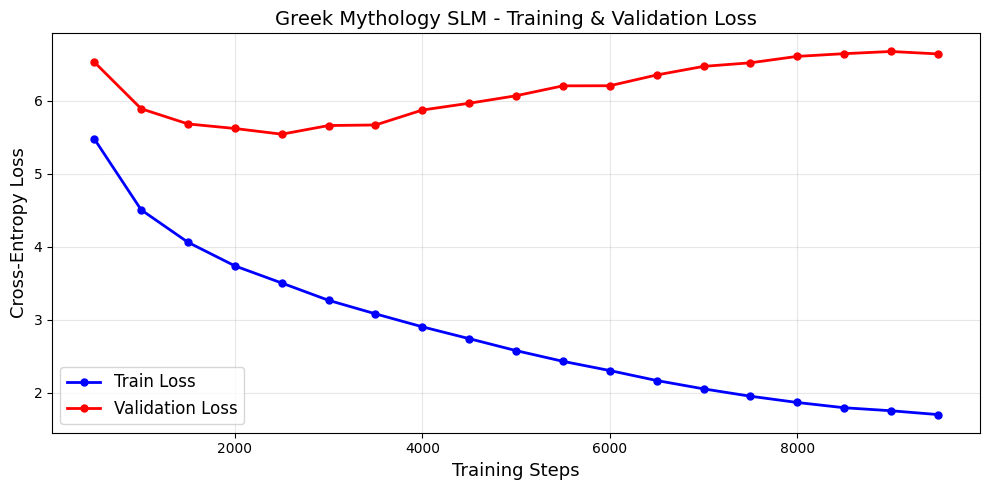

Loss curve saved to loss_curve.png


In [ ]:
import matplotlib.pyplot as plt

steps = [i * 500 for i in range(1, len(train_loss_list) + 1)]
plt.figure(figsize=(10, 5))
plt.plot(steps, train_loss_list,      'b-o', label='Train Loss',      linewidth=2, markersize=5)
plt.plot(steps, validation_loss_list, 'r-o', label='Validation Loss', linewidth=2, markersize=5)
plt.xlabel('Training Steps', fontsize=13)
plt.ylabel('Cross-Entropy Loss', fontsize=13)
plt.title('Greek Mythology SLM - Training & Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('loss_curve.png', dpi=150)
plt.show()
print('Loss curve saved to loss_curve.png')

## Step 10: Load Best Model and Run Inference

In [ ]:
import tiktoken

enc    = tiktoken.get_encoding('gpt2')
device = 'cuda' if torch.cuda.is_available() else 'cpu'

model_inference = GPT(config)
model_inference.load_state_dict(torch.load(best_model_params_path, map_location=device))
model_inference = model_inference.to(device)
model_inference.eval()
print('Best model loaded.')

Best model loaded.


In [ ]:
def generate_text(prompt, max_new_tokens=200, temperature=0.8, top_k=40):
    print(f'PROMPT: {prompt}')
    print('-' * 60)
    tokens  = enc.encode_ordinary(prompt)
    context = torch.tensor(tokens, dtype=torch.long, device=device).unsqueeze(0)
    with torch.no_grad():
        output = model_inference.generate(context, max_new_tokens=max_new_tokens,
                                          temperature=temperature, top_k=top_k)
    print(enc.decode(output.squeeze().tolist()))
    print('=' * 60)

# Sample 1
generate_text('Then Zeus, the father of gods and men, spoke from his golden throne upon Olympus:')


PROMPT: Then Zeus, the father of gods and men, spoke from his golden throne upon Olympus:
------------------------------------------------------------
Then Zeus, the father of gods and men, spoke from his golden throne upon Olympus:
is the child of Cronos and the goddesses also, and her
and bare a mortal men, and who was, she made aegis, and
and bare the gods. But when she bare Zeus and brought
s and. And the goddesses, and bare Zeus,
he was the, son of Zeus and the
thamemion and bare to gods.

(ll. 13-eyed Hera the king, rich-roake the son of
with her. And those who came to
the rich-men, glorious daughter of men of Zeus was, like Zeus, the son,
of Zeus, with the goddess, and brought her strong his father. But
herdying all the lord, the son of

(ll. TO APAnd she (ll. 1-eyed Athene. So she bare
Zeus the golden-eyed Athene, son of the son of Paus, and bare her and
bless


In [ ]:
# Sample 2
generate_text('Godlike Achilles drew his sword and stood before the walls of Troy, his heart filled with rage:')


PROMPT: Godlike Achilles drew his sword and stood before the walls of Troy, his heart filled with rage:
------------------------------------------------------------
Godlike Achilles drew his sword and stood before the walls of Troy, his heart filled with rage:
He had told his life, he was at him as he fell forth from the
the ground in his mouth. Then the sword was a spear fell into his
tonging his chariot, but he was at his face, nor did not make
with the ground, for he took his feet of his shield over his head as he was
he took off, and he was a spear from his eyes into his knees, and his
dectes; and he was he was not, as soon as he fell in
the head and his eyes.


“My friends, and I was I am in the house,” said he, “Telemachus,
you were going to say; I will be well, but now you can stay
yourself and will remember you. I cannot get home and tell me to
shall have been driven back again and tell me in my own
fool, and see if he is much as


In [ ]:
# Sample 3
generate_text('In the beginning there was Chaos, and from Chaos came the first gods of the earth and sky.')


PROMPT: In the beginning there was Chaos, and from Chaos came the first gods of the earth and sky.
------------------------------------------------------------
In the beginning there was Chaos, and from Chaos came the first gods of the earth and sky.
(ll. 1-9) And the son of Zeus,
(ll. 1-7) Leto, glorious Zeus the Muses, and mortal men who dwells, and
their children are of Zeus. And Zeus who, and Cronos, the gods: and the
and bare from Cronos and bare Cronos, and, as you and lovely
bless gods and the Slayer of men and the child of Cronos,
Zeus and Cronos and the gods and Cronos and glorious Zeus who bare
and lovely children of Zeus who who be the will with mortal men.


(ll. (ll. 448) ‘(ll. 17-hearted Hermes, to Apollo, lord, lord!
Aphrodite, who bare the blessed gods and glorious son of Zeus, who
fooly, the lord whom you are of rich-shooter.
(ll. 25-seeing Zeus........ bare her was


In [ ]:
# Sample 4
generate_text('Odysseus, the man of many devices, sailed across the wine-dark sea, longing for his home.')


PROMPT: Odysseus, the man of many devices, sailed across the wine-dark sea, longing for his home.
------------------------------------------------------------
Odysseus, the man of many devices, sailed across the wine-dark sea, longing for his home.

“Odwell-eyed goddess,” answered, “I wish that you are about the
shall have your son it?”

With these words heifer“Odyssey” in the house of Pylos, and
they should not be a great a god of good thing in all all.

Now, for all the suitors were in front of Ulysses. There, and the
that they bade the house, and they were like an end of them by the sun
was lying in the maids in the sea, and began to the suitors to
brought them, for they had been said, “you
you are in the gods are not going to ask them and come to go home, and bring
and the good things of them, and that the one is a great oath that
for when we have had not keep off on your own part for they
s. When


In [ ]:
# Sample 5 - lower temperature for more focused output
generate_text('Athena, goddess of wisdom, descended from the heavens', temperature=0.6)


PROMPT: Athena, goddess of wisdom, descended from the heavens
------------------------------------------------------------
Athena, goddess of wisdom, descended from the heavens.

(ll. 1-18) So, and the son of Cronos, the gods. But after the will
all that Zeus, the glorious daughter of Zeus, and the son of the
bless gods, and bare the Son of Cronos, the glorious
and Zeus, and bare him.
(ll. 1-7) bare the daughter of Zeus, and bare
s, the goddess, the daughter of Cronos, and bare
he, the son of Helicon, and the son of Cronos, and bare him.

(ll. 21-9) ‘.... bare him, rich-rops, the goddess, with the
and bare her and from Zeus in his heart, and he might,
and bare aegis.’

Fragment #3—Scholiast on Apollonius, and I. xiii. iii. 663


Fragment #4—Scholi


## Step 11: Summary

In [ ]:
print('=' * 50)
print('GREEK MYTHOLOGY SLM - SUMMARY')
print('=' * 50)
print(f'Domain          : Greek Mythology')
print(f'Data sources    : 6 texts from Project Gutenberg')
print(f'Corpus size     : ~{total_chars/1e6:.1f} MB ({total_words:,} words)')
print(f'Total tokens    : ~{total_tokens:,}')
print(f'Parameters      : {model.count_parameters():,}')
print(f'Architecture    : {config.n_layer}L {config.n_head}H {config.n_embd}D')
print(f'Context window  : {config.block_size} tokens')
print(f'Best val loss   : {best_val_loss:.4f}')
print('=' * 50)

# Uncomment to release GPU when done
# from google.colab import runtime
# runtime.unassign()

GREEK MYTHOLOGY SLM - SUMMARY
Domain          : Greek Mythology
Data sources    : 6 texts from Project Gutenberg
Corpus size     : ~2.9 MB (513,220 words)
Total tokens    : ~844,471
Parameters      : 51,082,752
Architecture    : 8L 8H 512D
Context window  : 256 tokens
Best val loss   : 5.5413
